In [1]:
import copy 
import pickle
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sklearn.metrics as metrics
import scipy.stats

from config import llm_review_path, home_path, supp_table_path

import sys 
sys.path.insert(1, home_path)
from common_functions import entropy, sort_dict_by_key

/Genomics/argo/users/jf9645/miniconda3/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
model_to_label = {
    'esm_1_43M' : "ESM-1 (43M)",
    'esm_1_85M': "ESM-1 (85M)",
    'esm_1_UR50S':"ESM-1 UR50 (670M)",
    'esm_1_UR50D':"ESM-1 UR50D (670M)",
    'esm_1_UR100':"ESM-1 UR100 (670M)",
    'esm_1b':"ESM-1b (650M)",
    'esm_1v':"ESM-1v (650M)",
    'esm_2_150M':"ESM-2 (150M)",
    'esm_2_15B':"ESM-2 (15B)",
    'esm_2_35M':"ESM-2 (35M)",
    'esm_2_3B':"ESM-2 (3B)",
    'esm_2_650M':"ESM-2 (650M)",
    'esm_2_8M':"ESM-2 (8M)",
    'protbert':"ProtBERT",
    "MAPLE" : "MAPLE"
}

### ProteinGym curated ClinVar Set 

In [3]:
table_results = []

human_proteins = pd.read_csv(f"{llm_review_path}data/uniprotkb_taxonomy_id_9606_AND_reviewed_2023_10_18.tsv", delimiter = "\t")

entry_name_to_length = dict(zip(human_proteins["Entry Name"].values, human_proteins["Length"].values))
entry_name_to_uniprot = dict(zip(human_proteins["Entry Name"].values, human_proteins["Entry"].values))

long_prot_df = pd.read_csv(f"{llm_review_path}masked_results/entropy_optimal_files_human_proteins/avg_site_entropy_long_proteins.csv.gz")

short_prot_df = pd.read_csv(f"{llm_review_path}masked_results/entropy_optimal_files_human_proteins/avg_site_entropy_short_proteins.csv.gz")

joined_df = pd.concat([short_prot_df, long_prot_df])

###############################

class_cutoff = 1
total_cutoff = 1

##############################

gene_to_res = {}

for model, sub_df in joined_df.groupby("model"):
    gene_to_ent = dict(zip(sub_df["entry_name"].values, sub_df["avg_site_entropy"].values))
    gene_to_res[model] = gene_to_ent
    
dfo = pd.DataFrame(gene_to_res)


model_to_auroc_performance = {}

model_list = [
    "protbert",
    "esm_1_43M",
    "esm_1_85M",
    "esm_1b",
    "esm_1_UR100",
    "esm_1_UR50D",
    "esm_1_UR50S",
    "esm_1v",
    "esm_2_150M",
    "esm_2_15B",
    "esm_2_3B",
    "esm_2_8M",
    "esm_2_35M",
    "esm_2_650M"
]

needed_entries = set()


for m in model_list:

    res_df = pd.read_csv(f"./other_clinvar_collections/pg_clinvar_scores/{m}.csv")

    auroc_res = []

    auroc_vals = {}

    for entry, sub_df in res_df.groupby("entry_name"):
        if entry not in dfo.index:
            continue 
        
        length = entry_name_to_length[entry]

        num_positive = len(sub_df.loc[sub_df["label"] == "Pathogenic"])
        num_negative = len(sub_df.loc[sub_df["label"] == "Benign"])

        if num_positive < class_cutoff or num_negative < class_cutoff or len(sub_df) < total_cutoff:
            continue 

        labels = list(map(lambda x : 1 if x == "Pathogenic" else 0 , sub_df["label"].values))
        scores = sub_df["vep_score"].values
        fpr, tpr, thresholds = metrics.roc_curve(labels, scores, pos_label=0)
        auroc = metrics.auc(fpr, tpr)
        auroc_res.append(auroc)
        auroc_vals[entry] = auroc
        needed_entries.add(entry)
        
        labels_str = "|".join(list(map(lambda x : str(x), labels)))
        scores_str = "|".join(list(map(lambda x : str(x), scores)))
        names_str = "|".join(sub_df["variant"].values)
        
        table_results.append([m, entry,names_str, labels_str, scores_str, auroc])

    model_to_auroc_performance[m] = auroc_vals
    
max_model = None 
max_val_mean = float("-inf")

for k, v in model_to_auroc_performance.items():
    mean_val = np.mean(list(v.values()))
    if mean_val >= max_val_mean:
        max_val_mean = mean_val
        max_model = k
        
print(len(v), max_val_mean, max_model, np.median(list(model_to_auroc_performance[max_model].values())))


dfo = pd.DataFrame(gene_to_res)

protbert_ent_vals = dfo["protbert"].to_dict()

dfo = dfo.drop(columns = ["protbert"])
dfo = dfo.sample(frac= 1, random_state = 2025)

dfo = dfo.loc[dfo.index.isin(list(model_to_auroc_performance["esm_2_8M"].keys()))] # getting only clinvar genes 

opt_ent_val = 1.0

model_choices = {}

for index, row in dfo.iterrows():
    models = np.asarray(row.index)
    ent_vals = row.values
    dist_from_opt = np.abs(ent_vals - opt_ent_val)
    am_ent = np.argmin(dist_from_opt)
    selected_model = models[am_ent]
    model_choices[index] = selected_model
    
maple_results = {}
for index, row in dfo.iterrows():
    chosen_model = model_choices[index]
    maple_results[index] = model_to_auroc_performance[chosen_model][index]
    
print("MAPLE", np.mean(list(maple_results.values())))


2173 0.8971687288655863 esm_1b 0.9814814814814815
MAPLE 0.9029009389611756


In [4]:
table_res_df_pg = pd.DataFrame(table_results, columns = ["model", "gene", "variants", "labels", "scores", "auroc", ])
# table_res_df_pg = table_res_df_pg.loc[table_res_df_pg["model"] != "protbert"]

is_maple_choice = []
entropy_val = []



for index, row in table_res_df_pg.iterrows():
    
    if row["model"] == "protbert":
        entropy_val.append(protbert_ent_vals[row["gene"]])
        is_maple_choice.append(False)
        
    else:
        ent_row = dfo.loc[row["gene"]]
        model_ent = ent_row[row["model"]]

        entropy_val.append(model_ent)

        maple_model_choice = model_choices[row["gene"]]
        is_maple_choice.append(maple_model_choice == row["model"])
    
table_res_df_pg["is_MAPLE_choice"] =  is_maple_choice
table_res_df_pg["average_site_entropy"] =  entropy_val
table_res_df_pg["source"] = "proteingym"
table_res_df_pg["model"] = table_res_df_pg["model"].apply(lambda x : model_to_label[x])

maple_df_pg = table_res_df_pg.loc[table_res_df_pg["is_MAPLE_choice"]]

print(np.mean(maple_df_pg['auroc'].values))

table_res_df_pg

0.9029009389611756


,model,gene,variants,labels,scores,auroc,is_MAPLE_choice,average_site_entropy,source
0,ProtBERT,1433G_HUMAN,R57C|R57H|K120R|D129E|R132C|Y133C|K152R|K162R|...,1|1|0|1|1|1|0|0|1|1|0,-7.872733133970219|-9.309282274191034|-6.50947...,0.928571,False,0.111707,proteingym
1,ProtBERT,2A5D_HUMAN,S24L|K145M|R146P|E197K|E198K|E200K|P201R|W207R...,0|1|0|1|1|1|1|1|1|1|1|1|1|1|1|0|0|1|0|0,-4.284151055330542|-14.232680285889607|-12.352...,0.821429,False,0.263301,proteingym
2,ProtBERT,2AAA_HUMAN,H87Y|S111A|A126V|R157Q|V158L|V162M|C174W|T178A...,0|0|0|0|0|0|1|1|1|1|1|1|1|1|1|1|0|1|0|0|1|0|0|...,-5.144512123310981|-8.193201103177573|-2.75112...,0.956044,False,0.244750,proteingym
3,ProtBERT,3BHS2_HUMAN,G2V|A10E|G12E|D74N|V75I|A82T|N100S|G129R|E142K...,0|1|1|0|0|1|1|1|1|1|1|1|1,-10.039436360955106|-14.165995623489762|-8.855...,0.733333,False,0.541995,proteingym
4,ProtBERT,3BHS7_HUMAN,H24R|R35G|E147K|R179H|T250A|A286T|L347P,0|0|1|0|0|0|0,-6.185835842787098|-5.090652392676386|-9.45969...,1.000000,False,0.258441,proteingym
...,...,...,...,...,...,...,...,...,...
30417,ESM-2 (650M),ZN711_HUMAN,I244T|H274R|A277T|K357R|M410I|K444Q,1|0|0|0|0|0,-0.314770484883538|-0.0431917692387751|0.29386...,0.800000,False,1.997385,proteingym
30418,ESM-2 (650M),ZN862_HUMAN,R218Q|A895T|A938T|T982A|R1114G,0|0|1|0|0,0.0026088456493155|-0.4977982161510511|-0.0391...,0.750000,False,2.976631,proteingym
30419,ESM-2 (650M),ZNHI3_HUMAN,S31L|V62I,1|0,-7.384743215965881|-0.6740692363505056,1.000000,False,1.760613,proteingym
30420,ESM-2 (650M),ZO2_HUMAN,V48A|L79R|Q128K|R215H|R233Q|S296N|G355R|T364M|...,1|1|0|0|0|0|0|0|1|0|0|1|0|0|0|1|0|0|0|0,-9.798163430668131|-12.041350312767811|1.10293...,0.973333,False,1.720333,proteingym


/tmp/ipykernel_3298449/1766523949.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(res, orient = "h", ax = ax, palette = my_pal,  zorder = 100, linewidth=1.2, edgecolor = "black")
/tmp/ipykernel_3298449/1766523949.py:131: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(res, orient = "h", ax = ax, palette = my_pal,  zorder = 100, linewidth=1.2, edgecolor = "black")
/tmp/ipykernel_3298449/1766523949.py:214: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(res, orient = "h", ax = ax, palette = my_pal,  zorder = 100, linewidth=1.2, edgecolor = "b

Text(0.5, 0, 'Average AUROC\n426 long proteins')

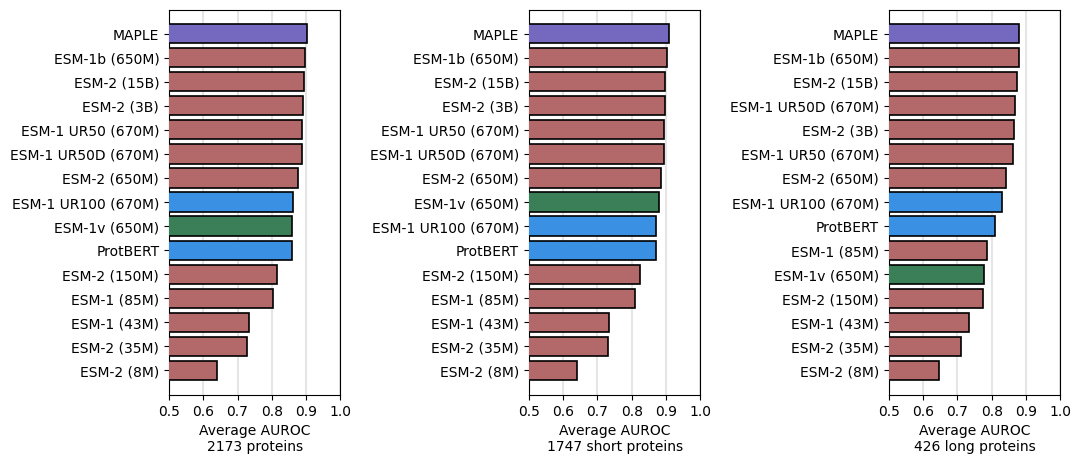

In [5]:
fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize = (11.5,5))
fig.subplots_adjust(wspace = 1.1)


# combined 
ax = ax1

res = []

for model, label in  model_to_label.items():
    
    if model == "MAPLE":
        auroc_res = copy.deepcopy(maple_results)
    else:
        auroc_res = model_to_auroc_performance[model]
    res.append([
        model, 
        label,
        np.mean(list(auroc_res.values()))
    ])
        
dfp = pd.DataFrame(res, columns = ["model", "label", "mean_auroc"])
dfp = dfp.sort_values(by = "mean_auroc", ascending = False)

model_to_color_1 = {'esm_1_43M': '#A3320B', 'esm_1_85M': '#A3320B', 'esm_1_UR50S': '#A3320B', 'esm_1_UR50D': '#A3320B', 'esm_1b': '#A3320B', 'esm_2_8M': '#A3320B', 'esm_2_35M': '#A3320B', 'esm_2_150M': '#A3320B', 'esm_2_650M': '#A3320B', 'esm_2_3B': '#A3320B', 'esm_2_15B': '#A3320B', 'esm_1_UR100': '#1E90FF', 'protbert': '#1E90FF', 'esm_1v': '#2E8B57'}

res = []
label = []
y = []
c = 0
err_vals = []

my_pal = {}

for index, row in dfp.iterrows():
    res.append(row["mean_auroc"])
    
    label.append(row["label"])
    y.append(c)
    if row["model"] == "MAPLE":
         color = "slateblue"
         my_pal[str(c)] = color
    else:
        color = model_to_color_1[row["model"]]
        if color == '#A3320B':
            color =  "#bf5c5d"
        my_pal[str(c)] = color
    c += 1

sns.barplot(res, orient = "h", ax = ax, palette = my_pal,  zorder = 100, linewidth=1.2, edgecolor = "black")
ax.set_xticks([0.5,0.6, 0.7,0.8,0.9,1.0])
ax.set_xlim(left = 0.5, right = 1.0)

for x_val in ax.get_xticks():
    ax.axvline(x = x_val, zorder = 0, color = "black", alpha = 0.1)
    
ax.set_ylim(top = -1, bottom = 15)
ax.set_yticks(ax.get_yticks())

ax.set_yticklabels(label)




###################################################################################

# only short proteins 

valid_proteins = set(short_prot_df["entry_name"].values)

model_to_short_vals = {}

for model, auroc_res in model_to_auroc_performance.items():
    
    model_short_vals = []
    for gene, auroc_performance in auroc_res.items():
        if gene in valid_proteins:
            model_short_vals.append(auroc_performance)
            
    model_to_short_vals[model] = model_short_vals

maple_short_vals = []

for k, v in maple_results.items():
    if k in valid_proteins:
        maple_short_vals.append(v)

model_to_short_vals["MAPLE"] = maple_short_vals

ax = ax2

res = []

for model, label in model_to_label.items():
    
    res.append([
        model, 
        label,
        np.mean(model_to_short_vals[model])
    ])
        
dfp = pd.DataFrame(res, columns = ["model", "label", "mean_auroc"])
dfp = dfp.sort_values(by = "mean_auroc", ascending = False)


model_to_color_1 = {'esm_1_43M': '#A3320B', 'esm_1_85M': '#A3320B', 'esm_1_UR50S': '#A3320B', 'esm_1_UR50D': '#A3320B', 'esm_1b': '#A3320B', 'esm_2_8M': '#A3320B', 'esm_2_35M': '#A3320B', 'esm_2_150M': '#A3320B', 'esm_2_650M': '#A3320B', 'esm_2_3B': '#A3320B', 'esm_2_15B': '#A3320B', 'esm_1_UR100': '#1E90FF', 'protbert': '#1E90FF', 'esm_1v': '#2E8B57'}

res = []
label = []
y = []
c = 0
err_vals = []

my_pal = {}

for index, row in dfp.iterrows():
    res.append(row["mean_auroc"])
    
    label.append(row["label"])
    y.append(c)
    if row["model"] == "MAPLE":
         color = "slateblue"
         my_pal[str(c)] = color
    else:
        color = model_to_color_1[row["model"]]
        if color == '#A3320B':
            color =  "#bf5c5d"
        my_pal[str(c)] = color
    c += 1

sns.barplot(res, orient = "h", ax = ax, palette = my_pal,  zorder = 100, linewidth=1.2, edgecolor = "black")
ax.set_xticks([0.5,0.6, 0.7,0.8,0.9,1.0])
ax.set_xlim(left = 0.5, right = 1.0)

for x_val in ax.get_xticks():
    ax.axvline(x = x_val, zorder = 0, color = "black", alpha = 0.1)
    
ax.set_ylim(top = -1, bottom = 15)
ax.set_yticks(ax.get_yticks())

ax.set_yticklabels(label)

ax.set_xlabel("Average AURUOC\n" + str(len(model_to_short_vals["esm_2_8M"])) + " short proteins")

# print(label)


###################################################################################

# only long proteins 

valid_proteins = set(long_prot_df["entry_name"].values)

model_to_long_vals = {}

for model, auroc_res in model_to_auroc_performance.items():
    
    model_long_vals = []
    for gene, auroc_performance in auroc_res.items():
        if gene in valid_proteins:
            model_long_vals.append(auroc_performance)
            
    model_to_long_vals[model] = model_long_vals

maple_long_vals = []

for k, v in maple_results.items():
    if k in valid_proteins:
        maple_long_vals.append(v)

model_to_long_vals["MAPLE"] = maple_long_vals

ax = ax3

res = []

for model, label in model_to_label.items():
    
    res.append([
        model, 
        label,
        np.mean(model_to_long_vals[model])
    ])
        
dfp = pd.DataFrame(res, columns = ["model", "label", "mean_auroc"])
dfp = dfp.sort_values(by = "mean_auroc", ascending = False)


model_to_color_1 = {'esm_1_43M': '#A3320B', 'esm_1_85M': '#A3320B', 'esm_1_UR50S': '#A3320B', 'esm_1_UR50D': '#A3320B', 'esm_1b': '#A3320B', 'esm_2_8M': '#A3320B', 'esm_2_35M': '#A3320B', 'esm_2_150M': '#A3320B', 'esm_2_650M': '#A3320B', 'esm_2_3B': '#A3320B', 'esm_2_15B': '#A3320B', 'esm_1_UR100': '#1E90FF', 'protbert': '#1E90FF', 'esm_1v': '#2E8B57'}

res = []
label = []
y = []
c = 0
err_vals = []

my_pal = {}

for index, row in dfp.iterrows():
    res.append(row["mean_auroc"])
    
    label.append(row["label"])
    y.append(c)
    if row["model"] == "MAPLE":
         color = "slateblue"
         my_pal[str(c)] = color
    else:
        color = model_to_color_1[row["model"]]
        if color == '#A3320B':
            color =  "#bf5c5d"
        my_pal[str(c)] = color
    c += 1

sns.barplot(res, orient = "h", ax = ax, palette = my_pal,  zorder = 100, linewidth=1.2, edgecolor = "black")
ax.set_xticks([0.5,0.6, 0.7,0.8,0.9,1.0])
ax.set_xlim(left = 0.5, right = 1.0)

for x_val in ax.get_xticks():
    ax.axvline(x = x_val, zorder = 0, color = "black", alpha = 0.1)
    
ax.set_ylim(top = -1, bottom = 15)
ax.set_yticks(ax.get_yticks())

ax.set_yticklabels(label)


###########################################

ax1.set_xlabel("Average AUROC\n" + str(len(model_to_auroc_performance["esm_2_8M"])) + " proteins")
ax2.set_xlabel("Average AUROC\n" + str(len(model_to_short_vals["esm_2_8M"])) + " short proteins")
ax3.set_xlabel("Average AUROC\n" + str(len(model_to_long_vals["esm_2_8M"])) + " long proteins")



### AlphaMissense Clinvar Set

In [6]:
human_proteins = pd.read_csv(f"{llm_review_path}data/uniprotkb_taxonomy_id_9606_AND_reviewed_2023_10_18.tsv", delimiter = "\t")

entry_name_to_length = dict(zip(human_proteins["Entry Name"].values, human_proteins["Length"].values))
entry_name_to_uniprot = dict(zip(human_proteins["Entry Name"].values, human_proteins["Entry"].values))

long_prot_df = pd.read_csv(f"{llm_review_path}masked_results/entropy_optimal_files_human_proteins/avg_site_entropy_long_proteins.csv.gz")

short_prot_df = pd.read_csv(f"{llm_review_path}masked_results/entropy_optimal_files_human_proteins/avg_site_entropy_short_proteins.csv.gz")

joined_df = pd.concat([short_prot_df, long_prot_df])

###############################

# joined_df = short_prot_df

class_cutoff = 1
num_cutoff = 1

##############################


df1 = pd.read_csv("./other_clinvar_collections/am_clinvar_variants.csv")
human_proteins = pd.read_csv(f"{llm_review_path}data/uniprotkb_taxonomy_id_9606_AND_reviewed_2023_10_18.tsv", delimiter = "\t")
human_prot_to_seq = dict(zip(human_proteins["Entry"].values, human_proteins["Sequence"].values))
entry_to_file_name = dict(zip(human_proteins["Entry"].values, human_proteins["Entry Name"].values))

entry_to_seq_len = dict(zip(human_proteins["Entry Name"].values, human_proteins["Length"].values))

df1["entry"] = df1["protein_variant"].apply(lambda x : x.split(":")[0])
df1["variant"] = df1["protein_variant"].apply(lambda x : x.split(":")[1])
df1["ref"] = df1["variant"].apply(lambda x : x[0])
df1["alt"] = df1["variant"].apply(lambda x : x[-1])
df1["pos"] = df1["variant"].apply(lambda x : int(x[1:-1]))



model_to_gene_auroc = {}

model_list = [
    "protbert",
    "esm_1_43M",
    "esm_1_85M",
    "esm_1b",
    "esm_1_UR100",
    "esm_1_UR50D",
    "esm_1_UR50S",
    "esm_1v",
    "esm_2_150M",
    "esm_2_15B",
    "esm_2_3B",
    "esm_2_8M",
    "esm_2_35M",
    "esm_2_650M"
]


for model in model_list:
    
    with open("./other_clinvar_collections/am_clinvar_scores/" + model + ".pkl", "rb") as f:
        data = pickle.load(f)
    f.close()

    gene_res = {}

    for gene, results in data.items():

        scores = results["scores"]
        labels = results["labels"] 
        x = []
        y = []
        if len(scores) < num_cutoff:
            continue

        for k, v in scores.items():
            x.append(v)
            y.append(labels[k])

        num_1 = np.sum(y)
        num_0 = len(y) - num_1

        if num_1 >= class_cutoff and num_0 >= class_cutoff:
            fpr, tpr, thresholds = metrics.roc_curve(y, x, pos_label=0)
            auroc = metrics.auc(fpr, tpr)
            gene_res[gene] = auroc

    model_to_gene_auroc[model] = gene_res
    
    
max_model = None 
max_val_mean = float("-inf")

for k, v in model_to_gene_auroc.items():
    mean_val = np.mean(list(v.values()))
    if mean_val >= max_val_mean:
        max_val_mean = mean_val
        max_model = k
        
print(len(v), max_val_mean, max_model, np.median(list(model_to_gene_auroc[max_model].values())))


dfo = pd.DataFrame(gene_to_res)
dfo = dfo.drop(columns = ["protbert"])
dfo = dfo.sample(frac= 1, random_state = 2025)
dfo = dfo.loc[dfo.index.isin(list(model_to_gene_auroc["esm_2_8M"].keys()))] # getting only clinvar genes 

opt_ent_val = 1

model_choices = {}

for index, row in dfo.iterrows():
    models = np.asarray(row.index)
    ent_vals = row.values
    dist_from_opt = np.abs(ent_vals - opt_ent_val)
    am_ent = np.argmin(dist_from_opt)
    selected_model = models[am_ent]
    model_choices[index] = selected_model
    
maple_results = {}
for index, row in dfo.iterrows():
    chosen_model = model_choices[index]
    maple_results[index] = model_to_gene_auroc[chosen_model][index]
    
print("MAPLE", np.mean(list(maple_results.values())))


2103 0.8960818545317076 esm_1b 0.9788235294117646
MAPLE 0.8980178882476603


/tmp/ipykernel_3298449/346676800.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(res, orient = "h", ax = ax, palette = my_pal,  zorder = 100, linewidth=1.2, edgecolor = "black")
/tmp/ipykernel_3298449/346676800.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(res, orient = "h", ax = ax, palette = my_pal,  zorder = 100, linewidth=1.2, edgecolor = "black")
/tmp/ipykernel_3298449/346676800.py:211: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(res, orient = "h", ax = ax, palette = my_pal,  zorder = 100, linewidth=1.2, edgecolor = "blac

Text(0.5, 0, 'Average AUROC\n522 long proteins')

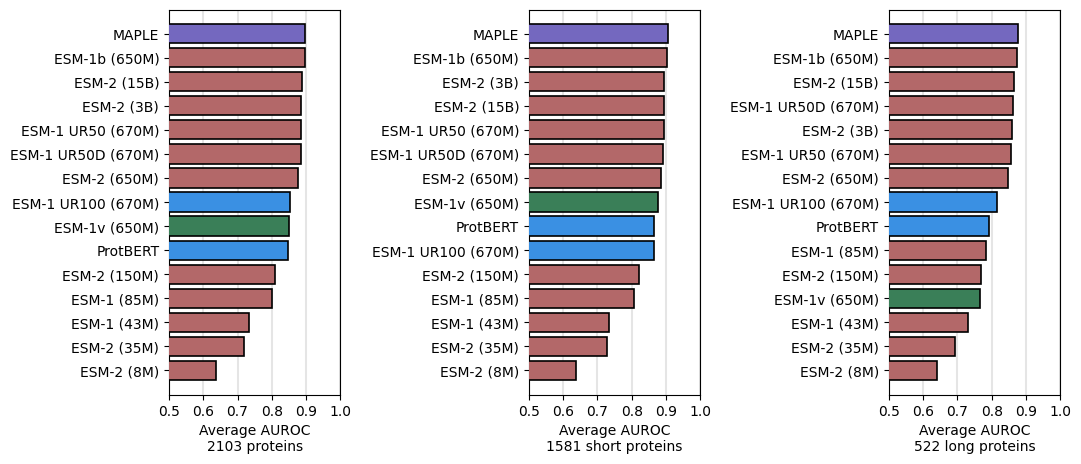

In [7]:
fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize = (11.5,5))
fig.subplots_adjust(wspace = 1.1)


# combined 
ax = ax1

res = []

for model, label in  model_to_label.items():
    
    if model == "MAPLE":
        auroc_res = copy.deepcopy(maple_results)
    else:
        auroc_res = model_to_gene_auroc[model]
    res.append([
        model, 
        label,
        np.mean(list(auroc_res.values()))
    ])
        
dfp = pd.DataFrame(res, columns = ["model", "label", "mean_auroc"])
dfp = dfp.sort_values(by = "mean_auroc", ascending = False)

model_to_color_1 = {'esm_1_43M': '#A3320B', 'esm_1_85M': '#A3320B', 'esm_1_UR50S': '#A3320B', 'esm_1_UR50D': '#A3320B', 'esm_1b': '#A3320B', 'esm_2_8M': '#A3320B', 'esm_2_35M': '#A3320B', 'esm_2_150M': '#A3320B', 'esm_2_650M': '#A3320B', 'esm_2_3B': '#A3320B', 'esm_2_15B': '#A3320B', 'esm_1_UR100': '#1E90FF', 'protbert': '#1E90FF', 'esm_1v': '#2E8B57'}

res = []
label = []
y = []
c = 0
err_vals = []

my_pal = {}

for index, row in dfp.iterrows():
    res.append(row["mean_auroc"])
    
    label.append(row["label"])
    y.append(c)
    if row["model"] == "MAPLE":
         color = "slateblue"
         my_pal[str(c)] = color
    else:
        color = model_to_color_1[row["model"]]
        if color == '#A3320B':
            color =  "#bf5c5d"
        my_pal[str(c)] = color
    c += 1

sns.barplot(res, orient = "h", ax = ax, palette = my_pal,  zorder = 100, linewidth=1.2, edgecolor = "black")
ax.set_xticks([0.5,0.6, 0.7,0.8,0.9,1.0])
ax.set_xlim(left = 0.5, right = 1.0)

for x_val in ax.get_xticks():
    ax.axvline(x = x_val, zorder = 0, color = "black", alpha = 0.1)
    
ax.set_ylim(top = -1, bottom = 15)
ax.set_yticks(ax.get_yticks())

ax.set_yticklabels(label)



###################################################################################

# only short proteins 

valid_proteins = set(short_prot_df["entry_name"].values)

model_to_short_vals = {}

for model, auroc_res in model_to_gene_auroc.items():
    
    model_short_vals = []
    for gene, auroc_performance in auroc_res.items():
        if gene in valid_proteins:
            model_short_vals.append(auroc_performance)
            
    model_to_short_vals[model] = model_short_vals

maple_short_vals = []

for k, v in maple_results.items():
    if k in valid_proteins:
        maple_short_vals.append(v)

model_to_short_vals["MAPLE"] = maple_short_vals

ax = ax2

res = []

for model, label in model_to_label.items():
    
    res.append([
        model, 
        label,
        np.mean(model_to_short_vals[model])
    ])
        
dfp = pd.DataFrame(res, columns = ["model", "label", "mean_auroc"])
dfp = dfp.sort_values(by = "mean_auroc", ascending = False)


model_to_color_1 = {'esm_1_43M': '#A3320B', 'esm_1_85M': '#A3320B', 'esm_1_UR50S': '#A3320B', 'esm_1_UR50D': '#A3320B', 'esm_1b': '#A3320B', 'esm_2_8M': '#A3320B', 'esm_2_35M': '#A3320B', 'esm_2_150M': '#A3320B', 'esm_2_650M': '#A3320B', 'esm_2_3B': '#A3320B', 'esm_2_15B': '#A3320B', 'esm_1_UR100': '#1E90FF', 'protbert': '#1E90FF', 'esm_1v': '#2E8B57'}

res = []
label = []
y = []
c = 0
err_vals = []

my_pal = {}

for index, row in dfp.iterrows():
    res.append(row["mean_auroc"])
    
    label.append(row["label"])
    y.append(c)
    if row["model"] == "MAPLE":
         color = "slateblue"
         my_pal[str(c)] = color
    else:
        color = model_to_color_1[row["model"]]
        if color == '#A3320B':
            color =  "#bf5c5d"
        my_pal[str(c)] = color
    c += 1

sns.barplot(res, orient = "h", ax = ax, palette = my_pal,  zorder = 100, linewidth=1.2, edgecolor = "black")
ax.set_xticks([0.5,0.6, 0.7,0.8,0.9,1.0])
ax.set_xlim(left = 0.5, right = 1.0)

for x_val in ax.get_xticks():
    ax.axvline(x = x_val, zorder = 0, color = "black", alpha = 0.1)
    
ax.set_ylim(top = -1, bottom = 15)
ax.set_yticks(ax.get_yticks())

ax.set_yticklabels(label)

# print(label)


###################################################################################

# only long proteins 

valid_proteins = set(long_prot_df["entry_name"].values)

model_to_long_vals = {}

for model, auroc_res in model_to_gene_auroc.items():
    
    model_long_vals = []
    for gene, auroc_performance in auroc_res.items():
        if gene in valid_proteins:
            model_long_vals.append(auroc_performance)
            
    model_to_long_vals[model] = model_long_vals

maple_long_vals = []

for k, v in maple_results.items():
    if k in valid_proteins:
        maple_long_vals.append(v)

model_to_long_vals["MAPLE"] = maple_long_vals

ax = ax3

res = []

for model, label in model_to_label.items():
    
    res.append([
        model, 
        label,
        np.mean(model_to_long_vals[model])
    ])
        
dfp = pd.DataFrame(res, columns = ["model", "label", "mean_auroc"])
dfp = dfp.sort_values(by = "mean_auroc", ascending = False)


model_to_color_1 = {'esm_1_43M': '#A3320B', 'esm_1_85M': '#A3320B', 'esm_1_UR50S': '#A3320B', 'esm_1_UR50D': '#A3320B', 'esm_1b': '#A3320B', 'esm_2_8M': '#A3320B', 'esm_2_35M': '#A3320B', 'esm_2_150M': '#A3320B', 'esm_2_650M': '#A3320B', 'esm_2_3B': '#A3320B', 'esm_2_15B': '#A3320B', 'esm_1_UR100': '#1E90FF', 'protbert': '#1E90FF', 'esm_1v': '#2E8B57'}

res = []
label = []
y = []
c = 0
err_vals = []

my_pal = {}

for index, row in dfp.iterrows():
    res.append(row["mean_auroc"])
    
    label.append(row["label"])
    y.append(c)
    if row["model"] == "MAPLE":
         color = "slateblue"
         my_pal[str(c)] = color
    else:
        color = model_to_color_1[row["model"]]
        if color == '#A3320B':
            color =  "#bf5c5d"
        my_pal[str(c)] = color
    c += 1

sns.barplot(res, orient = "h", ax = ax, palette = my_pal,  zorder = 100, linewidth=1.2, edgecolor = "black")
ax.set_xticks([0.5,0.6, 0.7,0.8,0.9,1.0])
ax.set_xlim(left = 0.5, right = 1.0)

for x_val in ax.get_xticks():
    ax.axvline(x = x_val, zorder = 0, color = "black", alpha = 0.1)
    
ax.set_ylim(top = -1, bottom = 15)
ax.set_yticks(ax.get_yticks())

ax.set_yticklabels(label)


###########################################

ax1.set_xlabel("Average AUROC\n" + str(len(model_to_gene_auroc["esm_2_8M"])) + " proteins")
ax2.set_xlabel("Average AUROC\n" + str(len(model_to_short_vals["esm_2_8M"])) + " short proteins")
ax3.set_xlabel("Average AUROC\n" + str(len(model_to_long_vals["esm_2_8M"])) + " long proteins")


### our set of variants and genes used in fig 5 

In [8]:
table_res = []


human_proteins = pd.read_csv(f"{llm_review_path}data/uniprotkb_taxonomy_id_9606_AND_reviewed_2023_10_18.tsv", delimiter = "\t")

entry_name_to_length = dict(zip(human_proteins["Entry Name"].values, human_proteins["Length"].values))
entry_name_to_uniprot = dict(zip(human_proteins["Entry Name"].values, human_proteins["Entry"].values))

long_prot_df = pd.read_csv(f"{llm_review_path}masked_results/entropy_optimal_files_human_proteins/avg_site_entropy_long_proteins.csv.gz")

short_prot_df = pd.read_csv(f"{llm_review_path}masked_results/entropy_optimal_files_human_proteins/avg_site_entropy_short_proteins.csv.gz")

joined_df = pd.concat([short_prot_df, long_prot_df])

###############################

class_cutoff = 1
num_cutoff = 1

##############################


model_to_label = {
    'esm_1_43M' : "ESM-1 (43M)",
    'esm_1_85M': "ESM-1 (85M)",
    'esm_1_UR50S':"ESM-1 UR50 (670M)",
    'esm_1_UR50D':"ESM-1 UR50D (670M)",
    'esm_1_UR100':"ESM-1 UR100 (670M)",
    'esm_1b':"ESM-1b (650M)",
    'esm_1v':"ESM-1v (650M)",
    'esm_2_150M':"ESM-2 (150M)",
    'esm_2_15B':"ESM-2 (15B)",
    'esm_2_35M':"ESM-2 (35M)",
    'esm_2_3B':"ESM-2 (3B)",
    'esm_2_650M':"ESM-2 (650M)",
    'esm_2_8M':"ESM-2 (8M)",
    'protbert':"ProtBERT",
    "MAPLE" : "MAPLE"
}

model_to_label_1 = dict(zip(model_to_label.values(), model_to_label.keys()))


long_protein_phi_selections = pd.read_csv(supp_table_path + "clinvar_misclassification_all_models_all_variants.csv")
model_to_auroc_results = {}


valid_prots = set(joined_df["entry_name"].values)

for model, sub_df in long_protein_phi_selections.groupby("model"):
    gene_auroc_vals = {}
    
    for gene, gene_df in sub_df.groupby("gene_name"):
        
        if gene not in valid_prots:
            continue
        
        b_lb_scores = gene_df.loc[gene_df["clinvar_annotation"] == "BLB"]
        p_lp_scores = gene_df.loc[gene_df["clinvar_annotation"] == "PLP"]
        
        labels = [1]*len(p_lp_scores) + [0]*len(b_lb_scores)
        
        predictions = list(p_lp_scores["score"].values) + list(b_lb_scores["score"].values) 
        
        fpr, tpr, thresholds = metrics.roc_curve(labels, predictions, pos_label=0)
        auroc = metrics.auc(fpr, tpr)

        gene_auroc_vals[gene] = auroc
        
        labels_str = "|".join(list(map(lambda x : str(x), labels)))
        scores_str = "|".join(list(map(lambda x : str(x), predictions)))
        names_str = "|".join(gene_df["name"].values)
        
        table_res.append([model_to_label_1[model], gene, names_str, labels_str, scores_str, auroc])
    
    model_to_auroc_results[model_to_label_1[model]] = gene_auroc_vals
    
    
max_model = None 
max_val_mean = float("-inf")

for k, v in model_to_auroc_results.items():
    mean_val = np.mean(list(v.values()))
    if mean_val >= max_val_mean:
        max_val_mean = mean_val
        max_model = k
        
print(len(v), max_val_mean, max_model, np.median(list(model_to_auroc_results[max_model].values())))



dfo = pd.DataFrame(gene_to_res)

protbert_ent_vals = dfo["protbert"].to_dict()

dfo = dfo.drop(columns = ["protbert"])
dfo = dfo.sample(frac= 1, random_state = 2025)
dfo = dfo.loc[dfo.index.isin(list(model_to_auroc_results["esm_2_8M"].keys()))] # getting only clinvar genes 

opt_ent_val = 1

model_choices = {}

for index, row in dfo.iterrows():
    models = np.asarray(row.index)
    ent_vals = row.values
    dist_from_opt = np.abs(ent_vals - opt_ent_val)
    am_ent = np.argmin(dist_from_opt)
    selected_model = models[am_ent]
    model_choices[index] = selected_model
    
maple_results = {}
for index, row in dfo.iterrows():
    chosen_model = model_choices[index]
    maple_results[index] = model_to_auroc_results[chosen_model][index]
    
print("MAPLE", np.mean(list(maple_results.values())))



1029 0.9045675413022353 esm_1b 0.9600000000000001
MAPLE 0.9067832847424686


In [9]:
table_res_df_balanced = pd.DataFrame(table_res, columns = ["model", "gene", "variants", "labels", "scores", "auroc", ])
# table_res_df_balanced = table_res_df_balanced.loc[table_res_df_balanced["model"] != "protbert"]

is_maple_choice = []
entropy_val = []



for index, row in table_res_df_balanced.iterrows():
    
    if row["model"] == "protbert":
        is_maple_choice.append(False)
        entropy_val.append(protbert_ent_vals[row["gene"]])
    else:
        
        ent_row = dfo.loc[row["gene"]]
        model_ent = ent_row[row["model"]]

        entropy_val.append(model_ent)

        maple_model_choice = model_choices[row["gene"]]
        is_maple_choice.append(maple_model_choice == row["model"])

table_res_df_balanced["is_MAPLE_choice"] =  is_maple_choice
table_res_df_balanced["average_site_entropy"] =  entropy_val
table_res_df_balanced["source"] = "balanced_clinvar_set"
table_res_df_balanced["model"] = table_res_df_balanced["model"].apply(lambda x : model_to_label[x])

maple_df_balanced = table_res_df_balanced.loc[table_res_df_balanced["is_MAPLE_choice"]]
print(np.mean(maple_df_balanced['auroc'].values))

0.9067832847424685


/tmp/ipykernel_3298449/1874974625.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(res, orient = "h", ax = ax, palette = my_pal,  zorder = 100, linewidth=1.2, edgecolor = "black")
/tmp/ipykernel_3298449/1874974625.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(res, orient = "h", ax = ax, palette = my_pal,  zorder = 100, linewidth=1.2, edgecolor = "black")
/tmp/ipykernel_3298449/1874974625.py:211: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(res, orient = "h", ax = ax, palette = my_pal,  zorder = 100, linewidth=1.2, edgecolor = "b

Text(0.5, 0, 'Average AUROC\n367 long proteins')

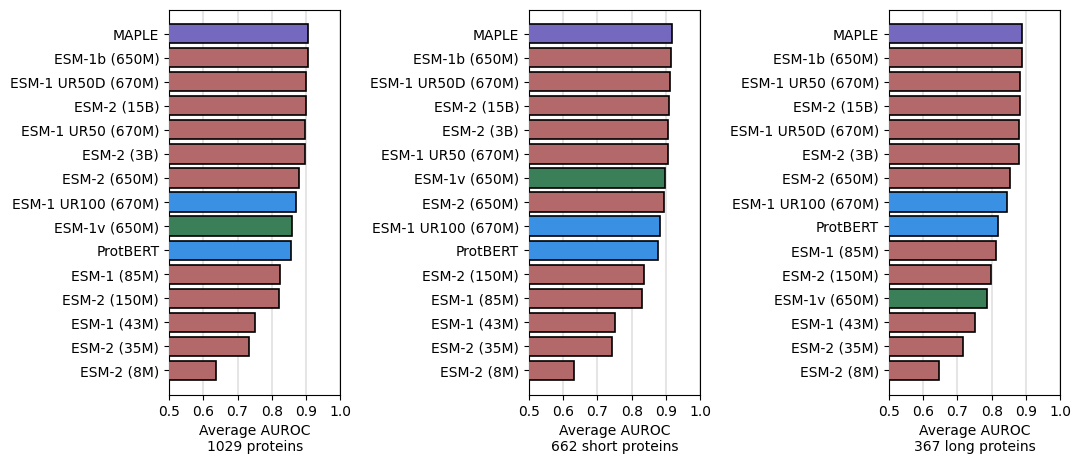

In [10]:
fig,(ax1,ax2,ax3) = plt.subplots(1,3,figsize = (11.5,5))
fig.subplots_adjust(wspace = 1.1)


# combined 
ax = ax1

res = []

for model, label in  model_to_label.items():
    
    if model == "MAPLE":
        auroc_res = copy.deepcopy(maple_results)
    else:
        auroc_res = model_to_auroc_results[model]
    res.append([
        model, 
        label,
        np.mean(list(auroc_res.values()))
    ])
        
dfp = pd.DataFrame(res, columns = ["model", "label", "mean_auroc"])
dfp = dfp.sort_values(by = "mean_auroc", ascending = False)

model_to_color_1 = {'esm_1_43M': '#A3320B', 'esm_1_85M': '#A3320B', 'esm_1_UR50S': '#A3320B', 'esm_1_UR50D': '#A3320B', 'esm_1b': '#A3320B', 'esm_2_8M': '#A3320B', 'esm_2_35M': '#A3320B', 'esm_2_150M': '#A3320B', 'esm_2_650M': '#A3320B', 'esm_2_3B': '#A3320B', 'esm_2_15B': '#A3320B', 'esm_1_UR100': '#1E90FF', 'protbert': '#1E90FF', 'esm_1v': '#2E8B57'}

res = []
label = []
y = []
c = 0
err_vals = []

my_pal = {}

for index, row in dfp.iterrows():
    res.append(row["mean_auroc"])
    
    label.append(row["label"])
    y.append(c)
    if row["model"] == "MAPLE":
         color = "slateblue"
         my_pal[str(c)] = color
    else:
        color = model_to_color_1[row["model"]]
        if color == '#A3320B':
            color =  "#bf5c5d"
        my_pal[str(c)] = color
    c += 1

sns.barplot(res, orient = "h", ax = ax, palette = my_pal,  zorder = 100, linewidth=1.2, edgecolor = "black")
ax.set_xticks([0.5,0.6, 0.7,0.8,0.9,1.0])
ax.set_xlim(left = 0.5, right = 1.0)

for x_val in ax.get_xticks():
    ax.axvline(x = x_val, zorder = 0, color = "black", alpha = 0.1)
    
ax.set_ylim(top = -1, bottom = 15)
ax.set_yticks(ax.get_yticks())

ax.set_yticklabels(label)



###################################################################################

# only short proteins 

valid_proteins = set(short_prot_df["entry_name"].values)

model_to_short_vals = {}

for model, auroc_res in model_to_auroc_results.items():
    
    model_short_vals = []
    for gene, auroc_performance in auroc_res.items():
        if gene in valid_proteins:
            model_short_vals.append(auroc_performance)
            
    model_to_short_vals[model] = model_short_vals

maple_short_vals = []

for k, v in maple_results.items():
    if k in valid_proteins:
        maple_short_vals.append(v)

model_to_short_vals["MAPLE"] = maple_short_vals

ax = ax2

res = []

for model, label in model_to_label.items():
    
    res.append([
        model, 
        label,
        np.mean(model_to_short_vals[model])
    ])
        
dfp = pd.DataFrame(res, columns = ["model", "label", "mean_auroc"])
dfp = dfp.sort_values(by = "mean_auroc", ascending = False)


model_to_color_1 = {'esm_1_43M': '#A3320B', 'esm_1_85M': '#A3320B', 'esm_1_UR50S': '#A3320B', 'esm_1_UR50D': '#A3320B', 'esm_1b': '#A3320B', 'esm_2_8M': '#A3320B', 'esm_2_35M': '#A3320B', 'esm_2_150M': '#A3320B', 'esm_2_650M': '#A3320B', 'esm_2_3B': '#A3320B', 'esm_2_15B': '#A3320B', 'esm_1_UR100': '#1E90FF', 'protbert': '#1E90FF', 'esm_1v': '#2E8B57'}

res = []
label = []
y = []
c = 0
err_vals = []

my_pal = {}

for index, row in dfp.iterrows():
    res.append(row["mean_auroc"])
    
    label.append(row["label"])
    y.append(c)
    if row["model"] == "MAPLE":
         color = "slateblue"
         my_pal[str(c)] = color
    else:
        color = model_to_color_1[row["model"]]
        if color == '#A3320B':
            color =  "#bf5c5d"
        my_pal[str(c)] = color
    c += 1

sns.barplot(res, orient = "h", ax = ax, palette = my_pal,  zorder = 100, linewidth=1.2, edgecolor = "black")
ax.set_xticks([0.5,0.6, 0.7,0.8,0.9,1.0])
ax.set_xlim(left = 0.5, right = 1.0)

for x_val in ax.get_xticks():
    ax.axvline(x = x_val, zorder = 0, color = "black", alpha = 0.1)
    
ax.set_ylim(top = -1, bottom = 15)
ax.set_yticks(ax.get_yticks())

ax.set_yticklabels(label)

# print(label)


###################################################################################

# only long proteins 

valid_proteins = set(long_prot_df["entry_name"].values)

model_to_long_vals = {}

for model, auroc_res in model_to_auroc_results.items():
    
    model_long_vals = []
    for gene, auroc_performance in auroc_res.items():
        if gene in valid_proteins:
            model_long_vals.append(auroc_performance)
            
    model_to_long_vals[model] = model_long_vals

maple_long_vals = []

for k, v in maple_results.items():
    if k in valid_proteins:
        maple_long_vals.append(v)

model_to_long_vals["MAPLE"] = maple_long_vals

ax = ax3

res = []

for model, label in model_to_label.items():
    
    res.append([
        model, 
        label,
        np.mean(model_to_long_vals[model])
    ])
        
dfp = pd.DataFrame(res, columns = ["model", "label", "mean_auroc"])
dfp = dfp.sort_values(by = "mean_auroc", ascending = False)


model_to_color_1 = {'esm_1_43M': '#A3320B', 'esm_1_85M': '#A3320B', 'esm_1_UR50S': '#A3320B', 'esm_1_UR50D': '#A3320B', 'esm_1b': '#A3320B', 'esm_2_8M': '#A3320B', 'esm_2_35M': '#A3320B', 'esm_2_150M': '#A3320B', 'esm_2_650M': '#A3320B', 'esm_2_3B': '#A3320B', 'esm_2_15B': '#A3320B', 'esm_1_UR100': '#1E90FF', 'protbert': '#1E90FF', 'esm_1v': '#2E8B57'}

res = []
label = []
y = []
c = 0
err_vals = []

my_pal = {}

for index, row in dfp.iterrows():
    res.append(row["mean_auroc"])
    
    label.append(row["label"])
    y.append(c)
    if row["model"] == "MAPLE":
         color = "slateblue"
         my_pal[str(c)] = color
    else:
        color = model_to_color_1[row["model"]]
        if color == '#A3320B':
            color =  "#bf5c5d"
        my_pal[str(c)] = color
    c += 1

sns.barplot(res, orient = "h", ax = ax, palette = my_pal,  zorder = 100, linewidth=1.2, edgecolor = "black")
ax.set_xticks([0.5,0.6, 0.7,0.8,0.9,1.0])
ax.set_xlim(left = 0.5, right = 1.0)

for x_val in ax.get_xticks():
    ax.axvline(x = x_val, zorder = 0, color = "black", alpha = 0.1)
    
ax.set_ylim(top = -1, bottom = 15)
ax.set_yticks(ax.get_yticks())

ax.set_yticklabels(label)

###########################################

ax1.set_xlabel("Average AUROC\n" + str(len(model_to_auroc_results["esm_2_8M"])) + " proteins")
ax2.set_xlabel("Average AUROC\n" + str(len(model_to_short_vals["esm_2_8M"])) + " short proteins")
ax3.set_xlabel("Average AUROC\n" + str(len(model_to_long_vals["esm_2_8M"])) + " long proteins")


In [11]:

supp_table_df = pd.concat([table_res_df_pg, table_res_df_balanced])
supp_table_df.to_csv(supp_table_path + "clinvar_auroc_vals_with_MAPLE_annotations.csv")

supp_table_df

,model,gene,variants,labels,scores,auroc,is_MAPLE_choice,average_site_entropy,source
0,ProtBERT,1433G_HUMAN,R57C|R57H|K120R|D129E|R132C|Y133C|K152R|K162R|...,1|1|0|1|1|1|0|0|1|1|0,-7.872733133970219|-9.309282274191034|-6.50947...,0.928571,False,0.111707,proteingym
1,ProtBERT,2A5D_HUMAN,S24L|K145M|R146P|E197K|E198K|E200K|P201R|W207R...,0|1|0|1|1|1|1|1|1|1|1|1|1|1|1|0|0|1|0|0,-4.284151055330542|-14.232680285889607|-12.352...,0.821429,False,0.263301,proteingym
2,ProtBERT,2AAA_HUMAN,H87Y|S111A|A126V|R157Q|V158L|V162M|C174W|T178A...,0|0|0|0|0|0|1|1|1|1|1|1|1|1|1|1|0|1|0|0|1|0|0|...,-5.144512123310981|-8.193201103177573|-2.75112...,0.956044,False,0.244750,proteingym
3,ProtBERT,3BHS2_HUMAN,G2V|A10E|G12E|D74N|V75I|A82T|N100S|G129R|E142K...,0|1|1|0|0|1|1|1|1|1|1|1|1,-10.039436360955106|-14.165995623489762|-8.855...,0.733333,False,0.541995,proteingym
4,ProtBERT,3BHS7_HUMAN,H24R|R35G|E147K|R179H|T250A|A286T|L347P,0|0|1|0|0|0|0,-6.185835842787098|-5.090652392676386|-9.45969...,1.000000,False,0.258441,proteingym
...,...,...,...,...,...,...,...,...,...
14401,ProtBERT,ZMY11_HUMAN,I80N|T455A|E302D|G180V|G84V|W562S|S419R|H281P|...,1|1|1|1|1|0|0|0|0|0,-15.30195523782202|-12.504948617920633|-10.540...,0.680000,False,0.092031,balanced_clinvar_set
14402,ProtBERT,ZN335_HUMAN,A49T|D78E|S110I|G159R|T344A|C467R|H487R|Y502C|...,1|1|1|1|1|0|0|0|0|0,-11.479169881475991|-9.92258742468113|-10.7747...,1.000000,False,1.670546,balanced_clinvar_set
14403,ProtBERT,ZN408_HUMAN,W88C|P272S|G39C|P534L|R663G|S392P|H455Y|R541C|...,1|1|1|1|1|0|0|0|0|0,-12.17747204868122|-15.180248295648957|-7.3431...,1.000000,False,1.696152,balanced_clinvar_set
14404,ProtBERT,ZNRF3_HUMAN,Y782H|Q212K|Y594C|T809M|F474L|P322R|C293Y|P179...,1|1|1|1|1|0|0|0|0|0,-13.264938347017855|-15.521000800273752|-5.688...,0.960000,False,1.065977,balanced_clinvar_set


In [19]:
wanted_genes = human_proteins.loc[
    (human_proteins["Length"] >= 1000) &
    (human_proteins["Length"] < 1022)
]["Entry Name"].values


In [20]:



models_wanted = ["esm_1_UR50S", "esm_1_UR50D", "esm_1_43M", "esm_1_85M", "esm_1b", "esm_1v", "esm_2_3B", "protbert", "esm_1_UR100", "esm_2_35M", "esm_2_8M", "esm_2_15B",  "esm_2_650M", "esm_2_150M" ]

model_to_pb_pos_to_entropy = {}

for model in models_wanted:
    
    model_path = llm_review_path + "masked_results/entropy_optimal_files_human_proteins/individual_model_scores_cleaned/" + model  + "/" 


    pb_pos_to_entropy = {i : [] for i in range(1,1001)}

    for gene in wanted_genes:
        pb_df = pd.read_csv(model_path + gene + ".csv.gz")

        pb_df = pb_df.loc[pb_df["aa_pos"] <= 1000]
        for pos_, pos_df in pb_df.groupby("aa_pos"):
            site_ent = entropy(pos_df["mut_probability"].values)
            pb_pos_to_entropy[pos_].append(site_ent)
            
    model_to_pb_pos_to_entropy[model] = pb_pos_to_entropy


Text(0.5, 1.0, 'ProtBERT masked site entropy\nproteins length [1000 - 1022]')

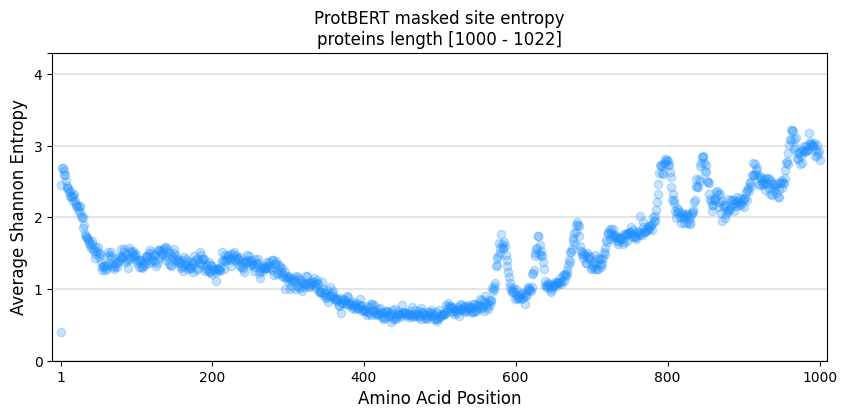

In [21]:
fig, ax = plt.subplots(figsize = (10,4))

pb_pos_to_entropy = model_to_pb_pos_to_entropy["protbert"]

pb_pos_to_entropy = sort_dict_by_key(pb_pos_to_entropy)

x = [] 
y = []

for pos_, ent_vals in pb_pos_to_entropy.items():
    x.append(pos_)
    y.append(np.mean(ent_vals))
    
ax.scatter(x,y, alpha = 0.25, color = "dodgerblue", zorder = 100)
ax.set_xlim(left = -10, right = 1010)
ax.set_xticks([1,200,400,600,800,1000])
ax.set_yticks([0,1,2,3,4, 4.3])
ax.set_yticklabels([0,1,2,3,4, ""])

for i in ax.get_yticks():
    ax.axhline(y = i, color = "black", alpha = 0.1, zorder = 1)
    
ax.set_xlabel("Amino Acid Position", fontsize = 12)
ax.set_ylabel("Average Shannon Entropy", fontsize = 12)
ax.set_title("ProtBERT masked site entropy\nproteins length [1000 - 1022]")

Text(0.5, 0.98, 'Masked Site Entropy by Sequence Position\nHuman Proteins Length 1000-1022')

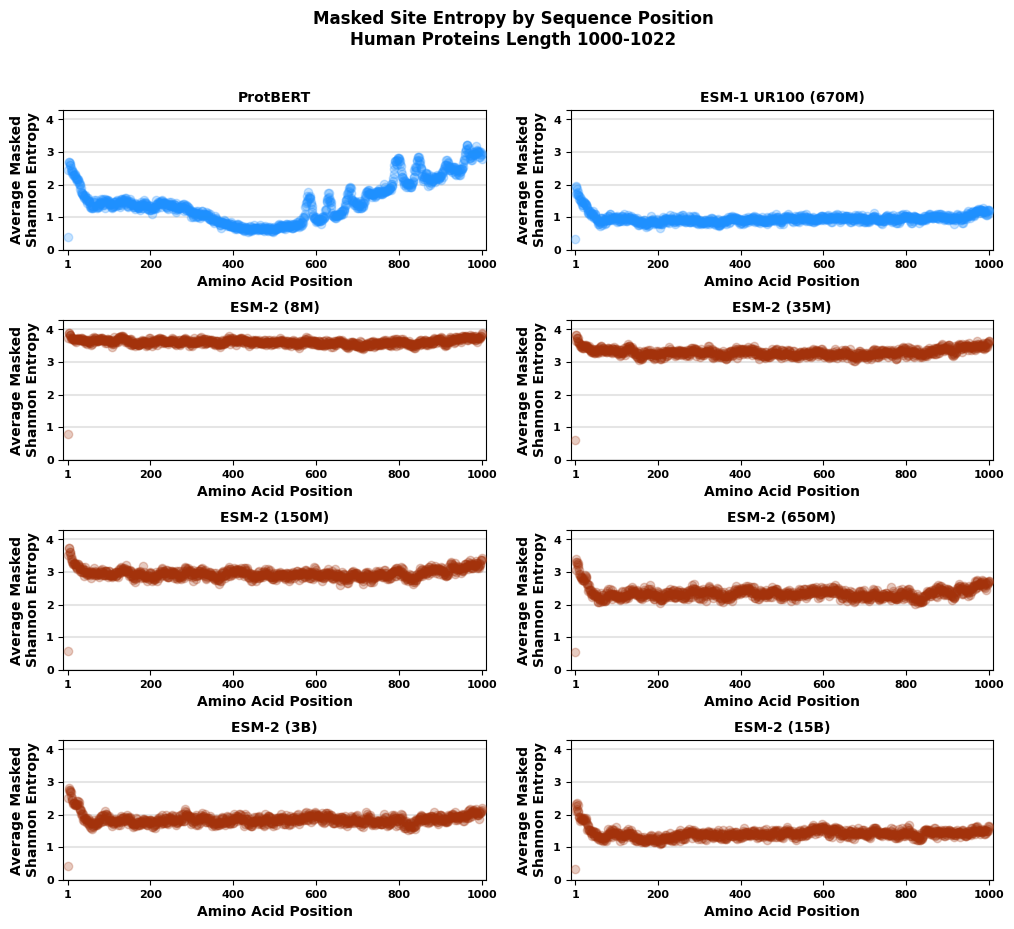

In [22]:
fig, axes = plt.subplots(4,2,figsize = (12,10))
axes = axes.ravel()
fig.subplots_adjust(hspace = 0.5)

for i, model in enumerate([ "protbert", "esm_1_UR100", "esm_2_8M" , "esm_2_35M" , "esm_2_150M" , "esm_2_650M", "esm_2_3B", "esm_2_15B", ]):
    ax= axes[i]
    
    pb_pos_to_entropy = model_to_pb_pos_to_entropy[model]

    pb_pos_to_entropy = sort_dict_by_key(pb_pos_to_entropy)


    x = [] 
    y = []

    for pos_, ent_vals in pb_pos_to_entropy.items():
        x.append(pos_)
        y.append(np.mean(ent_vals))

    ax.scatter(x,y, alpha = 0.25, color = model_to_color_1[model], zorder = 100)
    ax.set_xlim(left = -10, right = 1010)
    ax.set_xticks([1,200,400,600,800,1000])
    ax.set_xticklabels(ax.get_xticklabels(), fontsize = 8, fontweight = "bold")
    ax.set_yticks([0,1,2,3,4, 4.3])
    ax.set_yticklabels([0,1,2,3,4, ""], fontsize = 8, fontweight = "bold")

    for i in ax.get_yticks():
        ax.axhline(y = i, color = "black", alpha = 0.1, zorder = 1)

        
    ax.set_xlabel("Amino Acid Position", fontsize = 10, fontweight = "bold")
    ax.set_ylabel("Average Masked\nShannon Entropy", fontsize = 10, fontweight = "bold")
    ax.set_title(model_to_label[model], fontsize = 10, fontweight = "bold")
    
fig.suptitle("Masked Site Entropy by Sequence Position\nHuman Proteins Length 1000-1022", fontweight = "bold")

Text(0.5, 0.98, 'Masked Site Entropy by Sequence Position\nHuman Proteins Length 1000-1022')

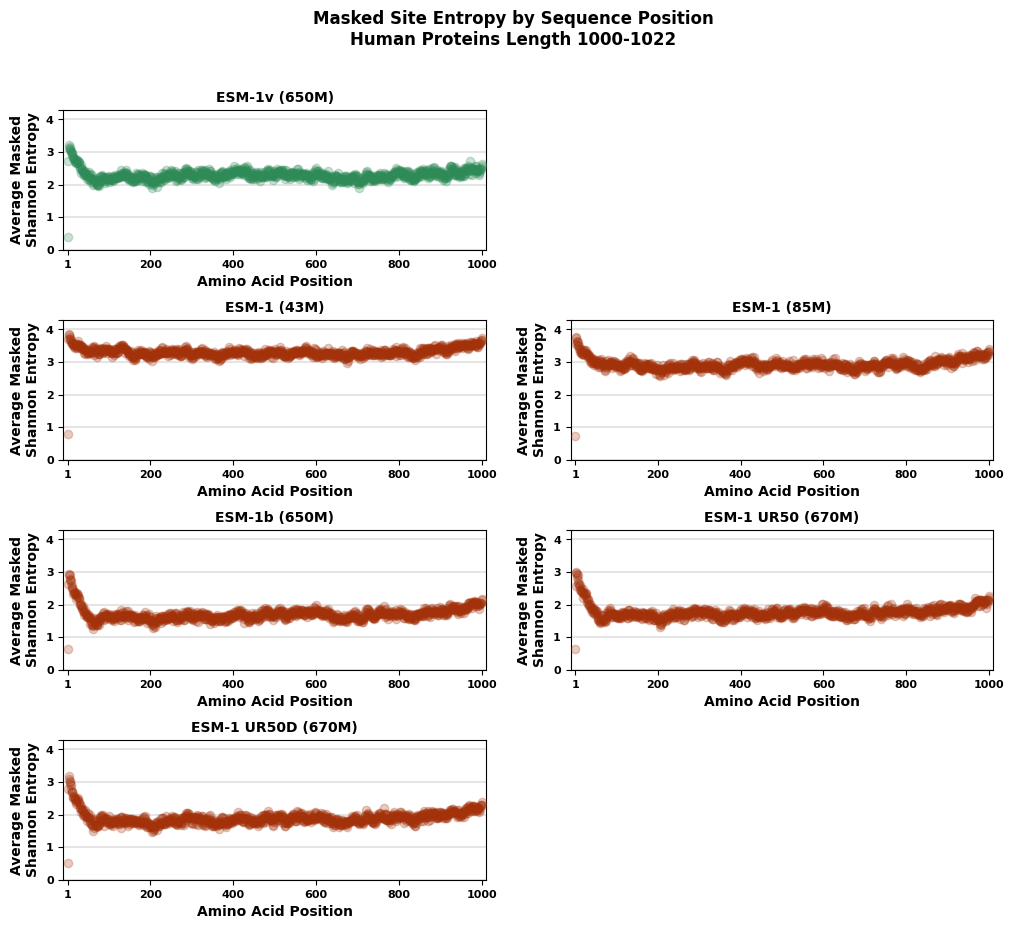

In [23]:
fig, axes = plt.subplots(4,2,figsize = (12,10))
axes = axes.ravel()
fig.subplots_adjust(hspace = 0.5)

counter = 0 
for  model in ["esm_1v","esm_1_43M", "esm_1_85M", "esm_1b", "esm_1_UR50S", "esm_1_UR50D"]:
    ax= axes[counter]
    
    pb_pos_to_entropy = model_to_pb_pos_to_entropy[model]

    pb_pos_to_entropy = sort_dict_by_key(pb_pos_to_entropy)


    x = [] 
    y = []

    for pos_, ent_vals in pb_pos_to_entropy.items():
        x.append(pos_)
        y.append(np.mean(ent_vals))

    ax.scatter(x,y, alpha = 0.25, color = model_to_color_1[model], zorder = 100)
    ax.set_xlim(left = -10, right = 1010)
    ax.set_xticks([1,200,400,600,800,1000])
    ax.set_xticklabels(ax.get_xticklabels(), fontsize = 8, fontweight = "bold")
    ax.set_yticks([0,1,2,3,4, 4.3])
    ax.set_yticklabels([0,1,2,3,4, ""], fontsize = 8, fontweight = "bold")

    for i in ax.get_yticks():
        ax.axhline(y = i, color = "black", alpha = 0.1, zorder = 1)

        
    ax.set_xlabel("Amino Acid Position", fontsize = 10, fontweight = "bold")
    ax.set_ylabel("Average Masked\nShannon Entropy", fontsize = 10, fontweight = "bold")
    ax.set_title(model_to_label[model], fontsize = 10, fontweight = "bold")
    
    if model == "esm_1v":
        counter += 2
    else:
        counter +=1 
        
fig.delaxes(axes[1])
fig.delaxes(axes[7])
    
fig.suptitle("Masked Site Entropy by Sequence Position\nHuman Proteins Length 1000-1022", fontweight = "bold")

In [24]:
len(wanted_genes)

105